In [1]:
import pickle
import os
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots, ensemble_eval
from neuralhydrology.nh_run import start_run, eval_run

In [2]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp_name ='EXP03'
default_order = ['SW_train','noSW_train','SW_test','noSW_test']
seqlen_options = [10,30,60,90,270]

## Grouping runs

In [3]:
## Sort to EXP03
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()

In [4]:
## Sort within EXP03
exp_count = eval_wrapper.check_exp_count(exp_runs)
exp_options = list(exp_count.keys())
exp_options.sort()
exp_options

EXP03_seqlen_no_sw_60_10basins :	 8
EXP03_seqlen_no_sw_10_10basins :	 8
EXP03_seqlen_wi_sw_90_10basins :	 8
EXP03_seqlen_wi_sw_10_10basins :	 8
EXP03_seqlen_no_sw_90_10basins :	 8
EXP03_seqlen_no_sw_30_10basins :	 8
EXP03_seqlen_no_sw_270_10basins :	 8
EXP03_seqlen_wi_sw_60_10basins :	 8
EXP03_seqlen_wi_sw_30_10basins :	 8
EXP03_seqlen_wi_sw_270_10basins :	 8


['EXP03_seqlen_no_sw_10_10basins',
 'EXP03_seqlen_no_sw_270_10basins',
 'EXP03_seqlen_no_sw_30_10basins',
 'EXP03_seqlen_no_sw_60_10basins',
 'EXP03_seqlen_no_sw_90_10basins',
 'EXP03_seqlen_wi_sw_10_10basins',
 'EXP03_seqlen_wi_sw_270_10basins',
 'EXP03_seqlen_wi_sw_30_10basins',
 'EXP03_seqlen_wi_sw_60_10basins',
 'EXP03_seqlen_wi_sw_90_10basins']

In [5]:
names_no_sw_10 = [run for run in all_runs if 'EXP03_seqlen_no_sw_10_10basins' in run]
names_wi_sw_10 = [run for run in all_runs if 'EXP03_seqlen_wi_sw_10_10basins' in run]

names_no_sw_30 = [run for run in all_runs if 'EXP03_seqlen_no_sw_30_10basins' in run]
names_wi_sw_30 = [run for run in all_runs if 'EXP03_seqlen_wi_sw_30_10basins' in run]

names_no_sw_60 = [run for run in all_runs if 'EXP03_seqlen_no_sw_60_10basins' in run]
names_wi_sw_60 = [run for run in all_runs if 'EXP03_seqlen_wi_sw_60_10basins' in run]

In [6]:
names_no_sw_90 = [run for run in all_runs if 'EXP03_seqlen_no_sw_90_10basins' in run]
names_wi_sw_90 = [run for run in all_runs if 'EXP03_seqlen_wi_sw_90_10basins' in run]

names_no_sw_270 = [run for run in all_runs if 'EXP03_seqlen_no_sw_270_10basins' in run]
names_wi_sw_270 = [run for run in all_runs if 'EXP03_seqlen_no_sw_270_10basins' in run]

## Evaluate results

In [7]:
tuple_10 = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_sw_10,wisw_exp_names = names_wi_sw_10,run_dir=all_runs_dir)
tuple_30 = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_sw_30,wisw_exp_names = names_no_sw_30,run_dir=all_runs_dir)
tuple_60 = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_sw_60,wisw_exp_names = names_wi_sw_60,run_dir=all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_seqlen_no_sw_10_10basins_3108_013106
# Validation:   0%|          | 0/10 [00:00<?, ?it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/1159302_p.k._le_roux.pkl')]
[PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/1834101_kainji.pkl')]
# Validation:  20%|██        | 2/10 [00:00<00:00, 10.47it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/3103450_betania.pkl')]
[PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/4148535_saluda.pkl')]
# Validation:  70%|███████   | 7/10 [00:01<00:00,  5.60it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/4152450_glen_canyon.pkl')]
[PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/5101500_wivenhoe.pkl')]
# Validation: 100%|██████████| 10/10 [00:01<00:00,  6.81it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_seqlen_no_sw_10_

In [8]:
tuple_90 = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_sw_90,wisw_exp_names = names_wi_sw_90,run_dir=all_runs_dir)
tuple_270 = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_sw_270,wisw_exp_names = names_wi_sw_270,run_dir=all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP03_seqlen_no_sw_90_10basins_3108_030401
# Validation:   0%|          | 0/10 [00:00<?, ?it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/1159302_p.k._le_roux.pkl')]
[PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/1834101_kainji.pkl')]
# Validation:  20%|██        | 2/10 [00:00<00:01,  6.90it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/3103450_betania.pkl')]
[PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/4148535_saluda.pkl')]
# Validation:  40%|████      | 4/10 [00:00<00:00,  7.27it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/4150600_livingston_dam.pkl')]
[PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/4150680_sam_rayburn_dam_and_reservoir.pkl')]
# Validation:  60%|██████    | 6/10 [00:00<00:00,  8.54it/s][PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/41507

In [10]:
zipped_metrics = list(zip(tuple_10,tuple_30,tuple_60,tuple_90,tuple_270))

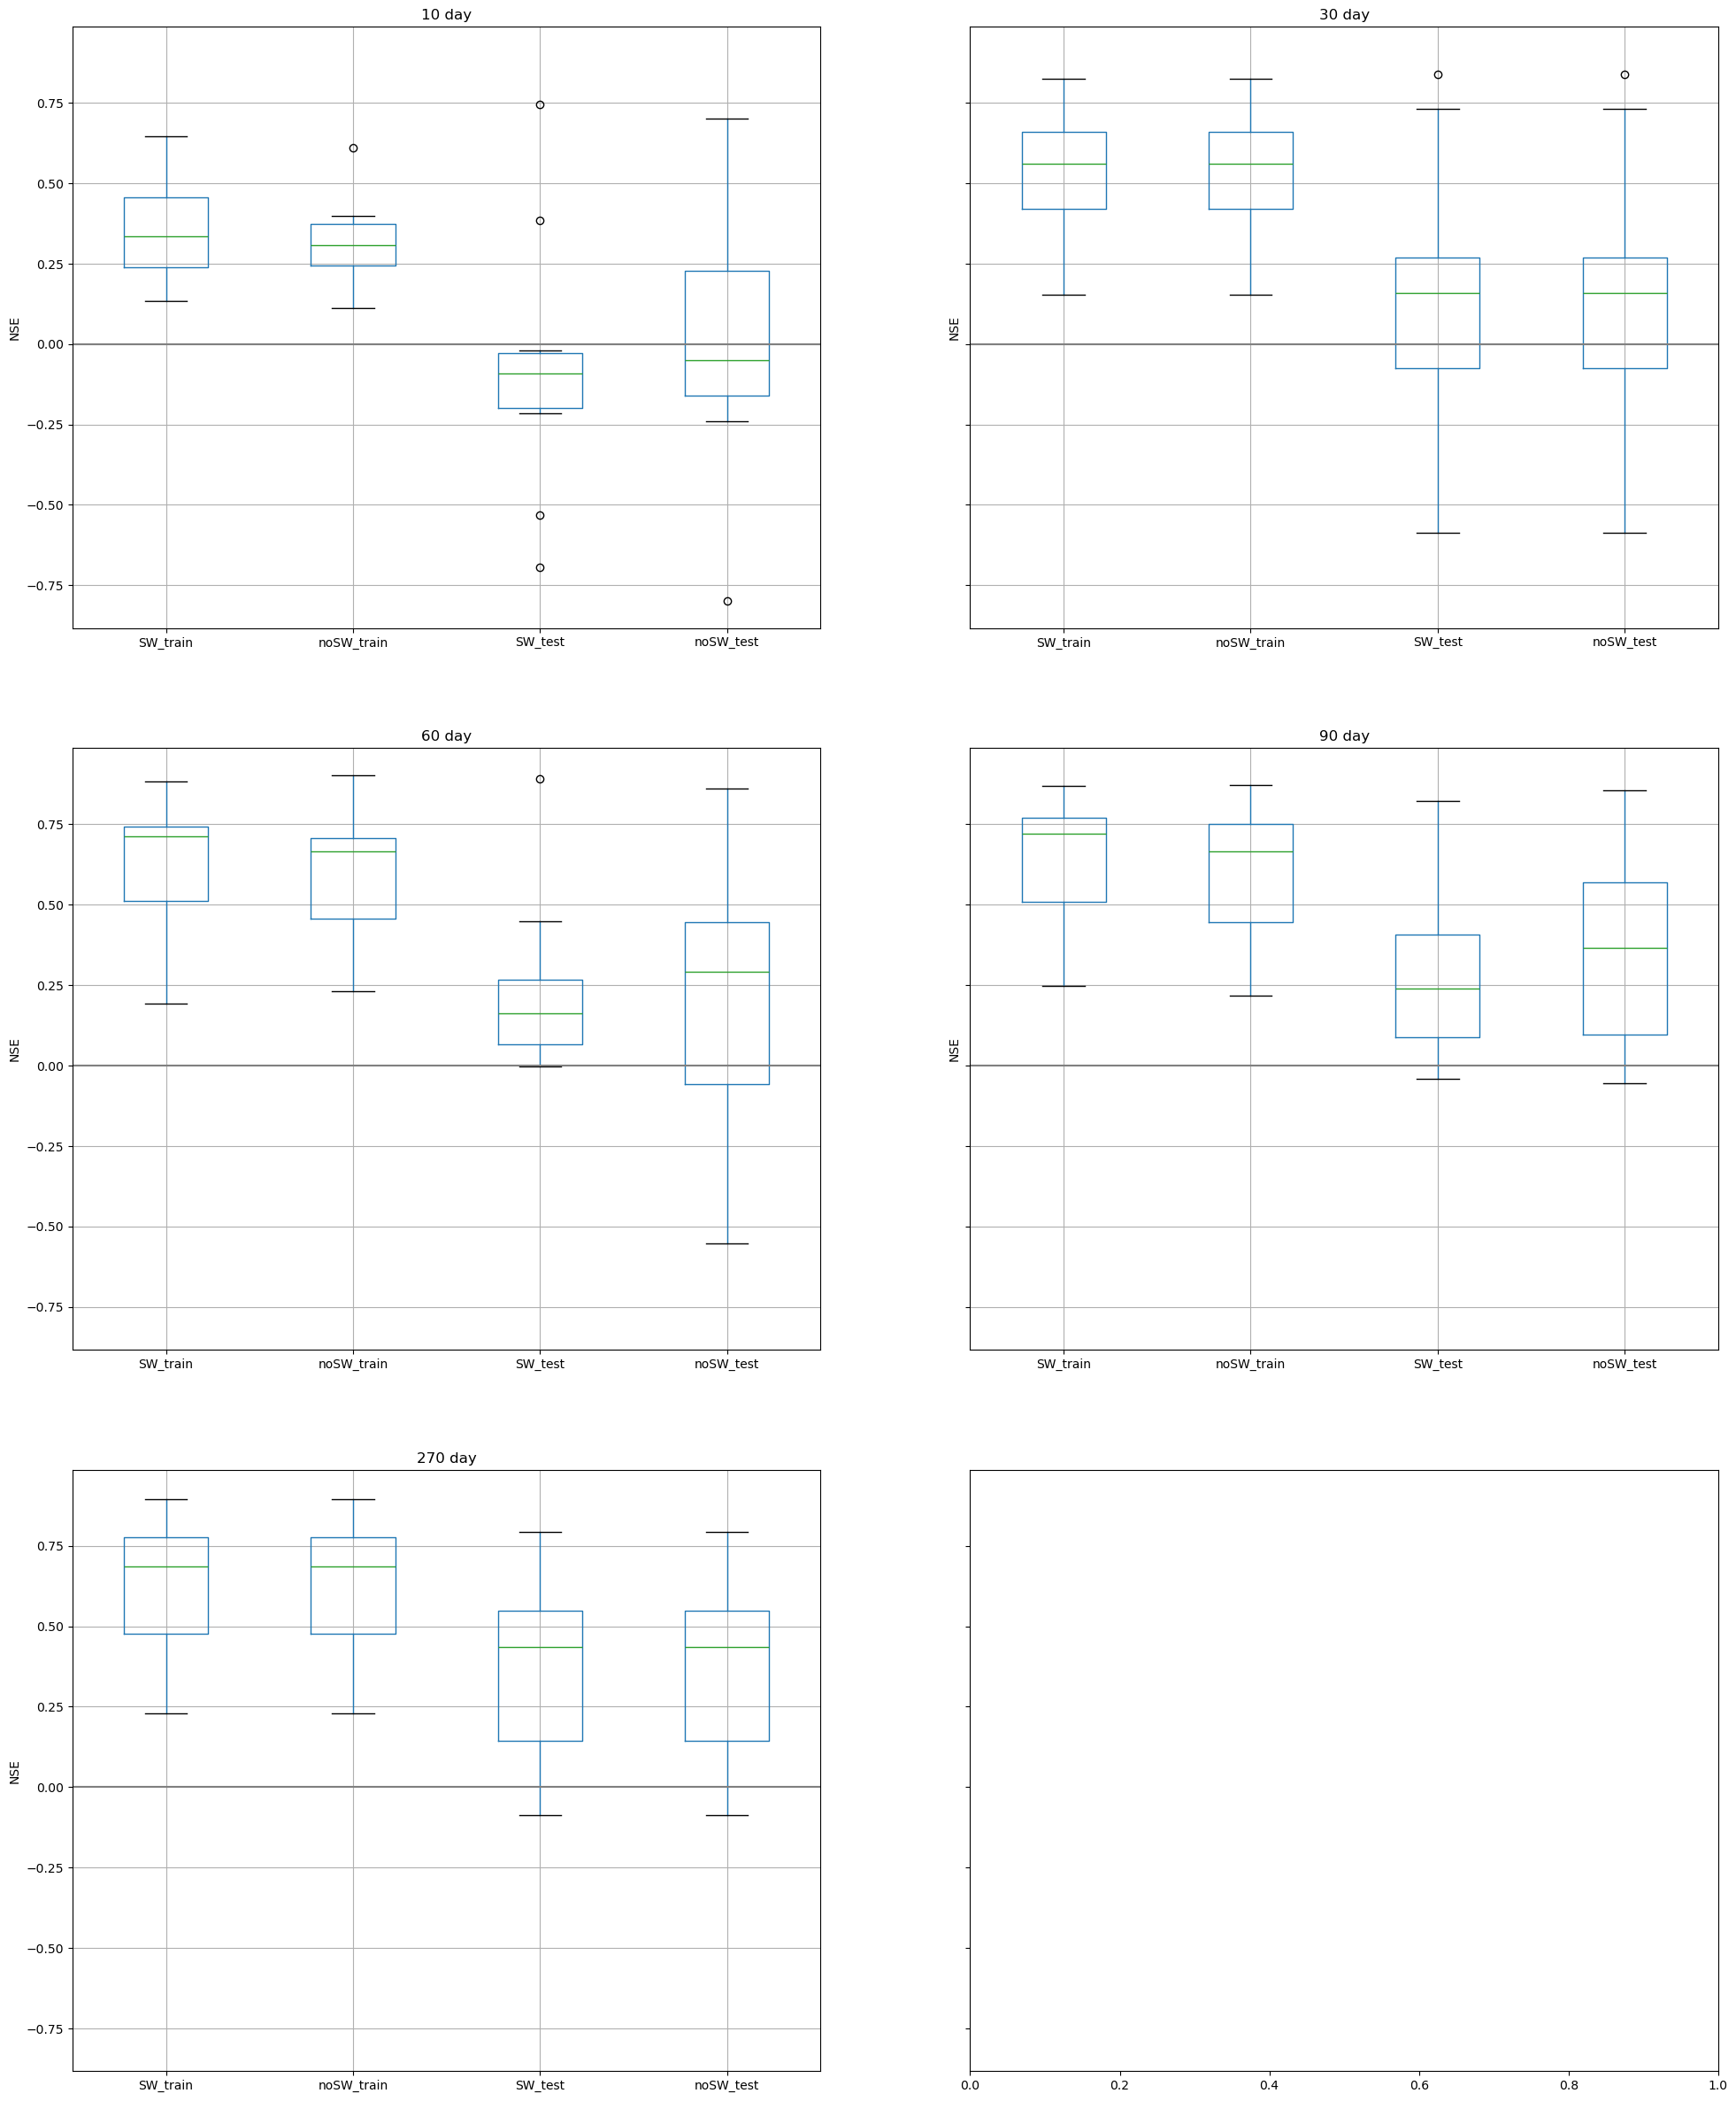

In [9]:
fig, axs = plt.subplots(3, 2, figsize=(24, 30),sharey=True)
seq10_nse_df = comp_plots.boxplot_from_tuple(tuple_10,ax=axs[0,0],tuple_names=default_order,exp_name = '10 day')
seq30_nse_df = comp_plots.boxplot_from_tuple(tuple_30,ax=axs[0,1],tuple_names=default_order,exp_name = '30 day')
seq60_nse_df = comp_plots.boxplot_from_tuple(tuple_60,ax=axs[1,0],tuple_names=default_order,exp_name = '60 day')
seq90_nse_df = comp_plots.boxplot_from_tuple(tuple_90,ax=axs[1,1],tuple_names=default_order,exp_name = '90 day')
seq270_nse_df = comp_plots.boxplot_from_tuple(tuple_270,ax=axs[2,0],tuple_names=default_order,exp_name = '270 day')

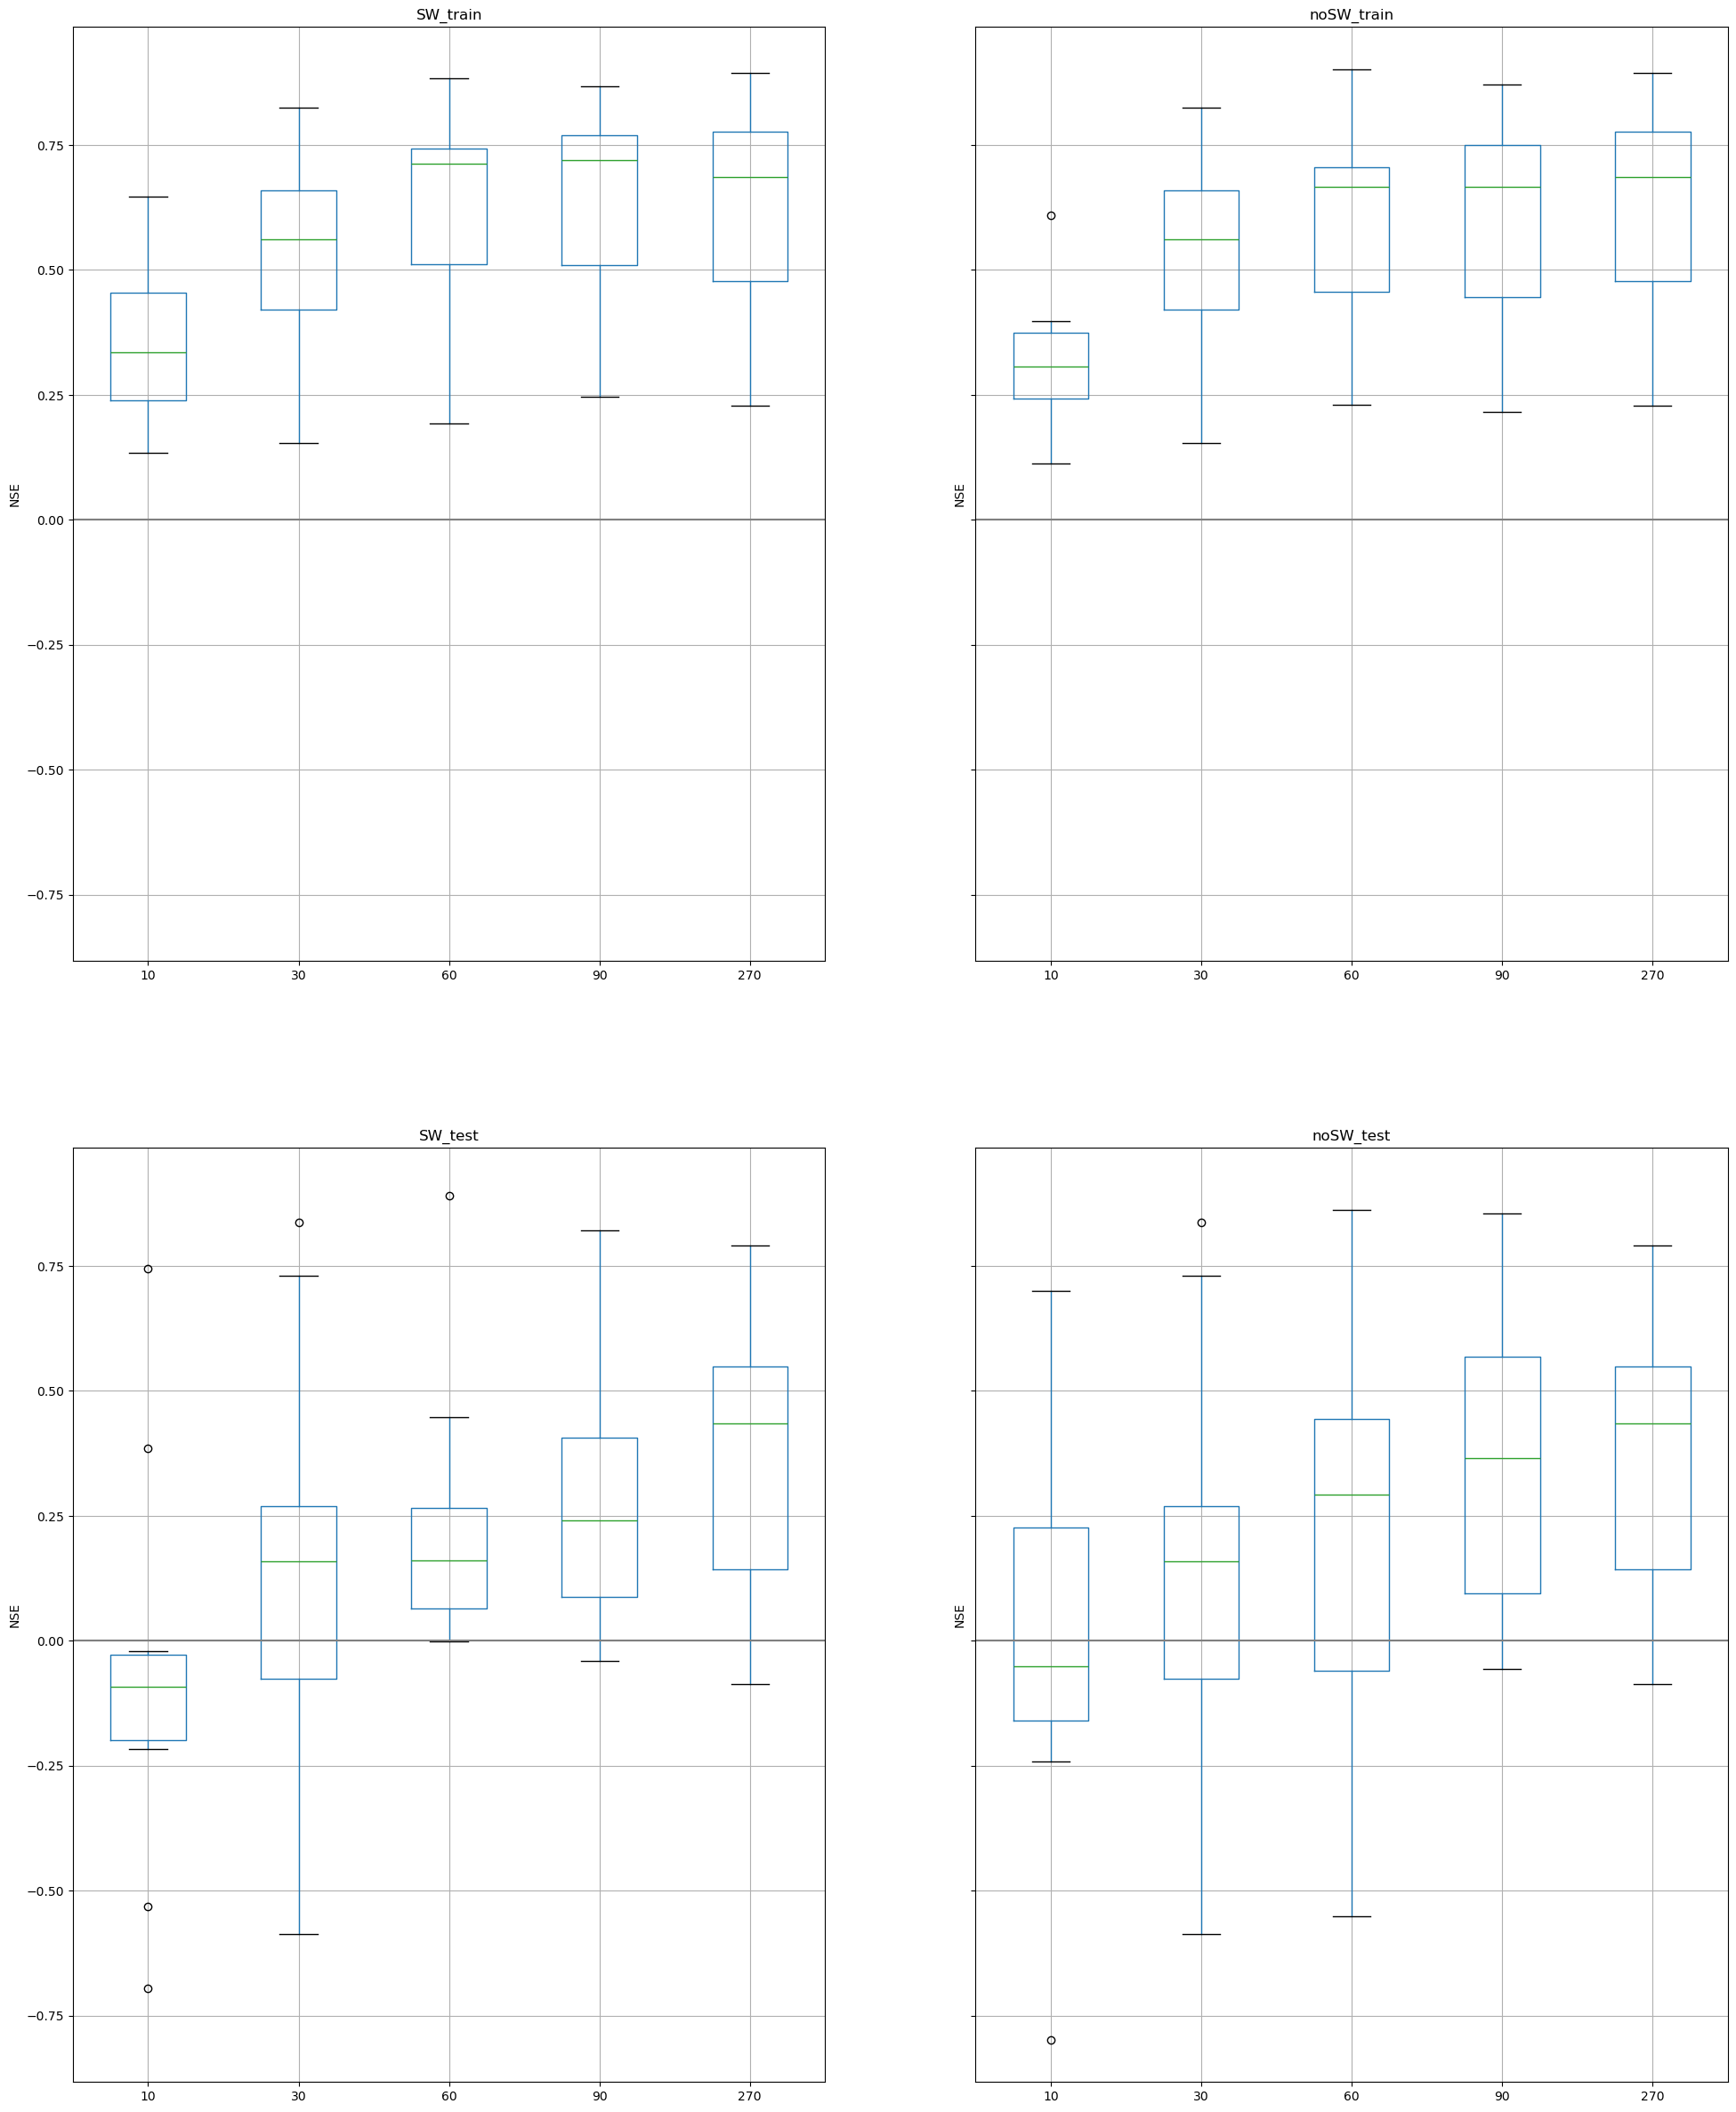

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(24, 30),sharey=True)
seq10_nse_df = comp_plots.boxplot_from_tuple(zipped_metrics[0],ax=axs[0,0],tuple_names=seqlen_options,exp_name = default_order[0])
seq30_nse_df = comp_plots.boxplot_from_tuple(zipped_metrics[1],ax=axs[0,1],tuple_names=seqlen_options,exp_name = default_order[1])
seq60_nse_df = comp_plots.boxplot_from_tuple(zipped_metrics[2],ax=axs[1,0],tuple_names=seqlen_options,exp_name = default_order[2])
seq90_nse_df = comp_plots.boxplot_from_tuple(zipped_metrics[3],ax=axs[1,1],tuple_names=seqlen_options,exp_name = default_order[3])